# WEEK 5 – DATA 5600
## Assignment #5: CNN and DNN for Image Classification
**Pol Monné Parera (L30170743)**  
pmonneparera@lewisu.edu  
Spring 2026

### 1. Imports

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.16.2


### 2. Load and Preprocess CIFAR-10

In [9]:
# Load CIFAR-10
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

print(f"Train shape: {x_train_raw.shape}, Test shape: {x_test_raw.shape}")
print(f"CIFAR-10 classes: airplane(0), automobile(1), bird(2), cat(3), deer(4),")
print(f"                  dog(5), frog(6), horse(7), ship(8), truck(9)")

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Binary mapping: vehicles (0,1,8,9) -> 1, animals (2,3,4,5,6,7) -> 0
VEHICLE_CLASSES = {0, 1, 8, 9}

def make_binary(y):
    return (np.isin(y.flatten(), list(VEHICLE_CLASSES))).astype(np.float32)

y_train_bin = make_binary(y_train_raw)
y_test_bin = make_binary(y_test_raw)

print(f"\nBinary label distribution (train): animals={np.sum(y_train_bin==0)}, vehicles={np.sum(y_train_bin==1)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step
Train shape: (50000, 32, 32, 3), Test shape: (10000, 32, 32, 3)
CIFAR-10 classes: airplane(0), automobile(1), bird(2), cat(3), deer(4),
                  dog(5), frog(6), horse(7), ship(8), truck(9)

Binary label distribution (train): animals=30000, vehicles=20000


In [10]:
# Normalize to [0, 1]
x_train_norm = x_train_raw.astype('float32') / 255.0
x_test_norm = x_test_raw.astype('float32') / 255.0

# For DNN: flatten to 3072-dim vector
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print(f"DNN input shape: {x_train_flat.shape}")
print(f"CNN input shape: {x_train_norm.shape}")

DNN input shape: (50000, 3072)
CNN input shape: (50000, 32, 32, 3)


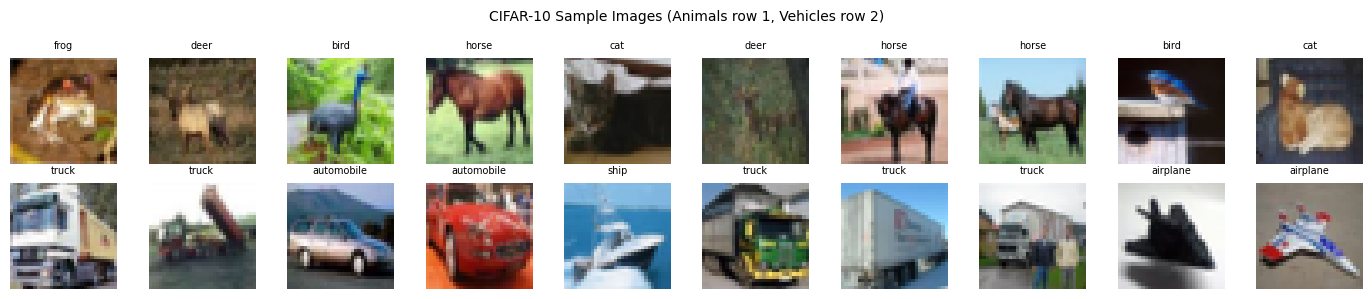

In [41]:
# Visualize a few samples
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i in range(10):
    idx_animal = np.where(y_train_bin == 0)[0][i]
    axes[0, i].imshow(x_train_raw[idx_animal])
    axes[0, i].set_title(CLASS_NAMES[y_train_raw[idx_animal][0]], fontsize=7)
    axes[0, i].axis('off')

    idx_vehicle = np.where(y_train_bin == 1)[0][i]
    axes[1, i].imshow(x_train_raw[idx_vehicle])
    axes[1, i].set_title(CLASS_NAMES[y_train_raw[idx_vehicle][0]], fontsize=7)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Animal\nsamples', fontsize=8)
axes[1, 0].set_ylabel('Vehicle\nsamples', fontsize=8)
plt.suptitle('CIFAR-10 Sample Images (Animals row 1, Vehicles row 2)', fontsize=10)
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()

### 3. DNN Model

In [53]:
def build_dnn(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='DNN')
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

dnn = build_dnn(input_dim=3072)
dnn.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,737,729 (6.63 MB)

 Trainable params: 1,737,729 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

dnn_history = dnn.fit(
    x_train_flat, y_train_bin,
    batch_size=128,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7654 - loss: 0.5105 - val_accuracy: 0.8164 - val_loss: 0.4434
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8027 - loss: 0.4507 - val_accuracy: 0.8208 - val_loss: 0.4351
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8102 - loss: 0.4376 - val_accuracy: 0.8362 - val_loss: 0.4148
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8166 - loss: 0.4264 - val_accuracy: 0.8410 - val_loss: 0.4194
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8213 - loss: 0.4201 - val_accuracy: 0.8298 - val_loss: 0.4112
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8245 - loss: 0.4145 - val_accuracy: 0.8418 - val_loss: 0.4124
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8286 - loss: 0.4077 - val_accuracy: 0.8430 - val_loss: 0.3917
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8316 - loss: 0.4007 - val_accuracy:

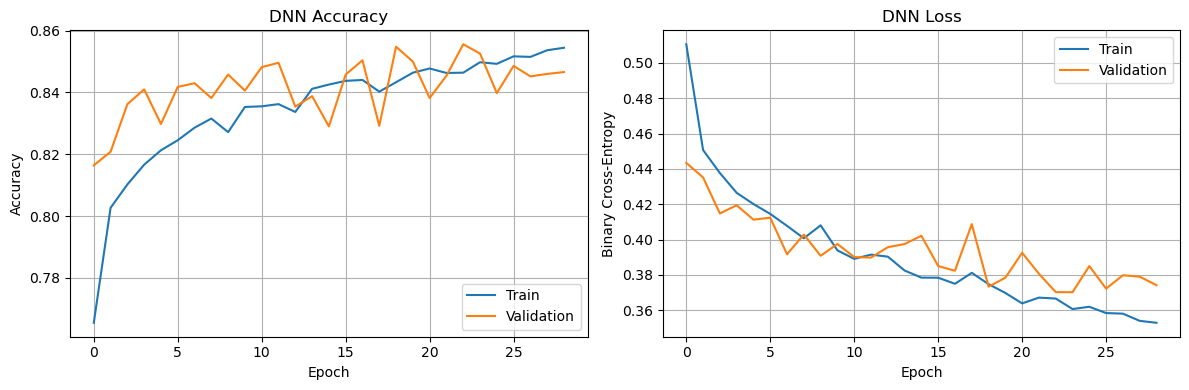

Saved: dnn_training_curves.png


In [43]:
# DNN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(dnn_history.history['accuracy'], label='Train')
ax1.plot(dnn_history.history['val_accuracy'], label='Validation')
ax1.set_title('DNN Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(dnn_history.history['loss'], label='Train')
ax2.plot(dnn_history.history['val_loss'], label='Validation')
ax2.set_title('DNN Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary Cross-Entropy')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('dnn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: dnn_training_curves.png")

In [16]:
# DNN evaluation
dnn_probs = dnn.predict(x_test_flat, verbose=0).flatten()
dnn_preds = (dnn_probs >= 0.5).astype(int)
dnn_acc = accuracy_score(y_test_bin, dnn_preds)

print(f"DNN Test Accuracy: {dnn_acc * 100:.2f}%")
print()
print(classification_report(y_test_bin, dnn_preds, target_names=['Animal', 'Vehicle']))

DNN Test Accuracy: 85.46%

              precision    recall  f1-score   support

      Animal       0.85      0.93      0.88      6000
     Vehicle       0.87      0.75      0.80      4000

    accuracy                           0.85     10000
   macro avg       0.86      0.84      0.84     10000
weighted avg       0.86      0.85      0.85     10000



### 4. CNN Model

In [18]:
def build_cnn(input_shape):
    model = Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN')
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn = build_cnn(input_shape=(32, 32, 3))
cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,115,041 (4.25 MB)

 Trainable params: 1,114,849 (4.25 MB)

 Non-trainable params: 192 (768.00 B)

In [19]:
early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cnn_history = cnn.fit(
    x_train_norm, y_train_bin,
    batch_size=64,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop_cnn],
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.8820 - loss: 0.3230 - val_accuracy: 0.9098 - val_loss: 0.2219
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.9157 - loss: 0.2150 - val_accuracy: 0.9262 - val_loss: 0.1986
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9272 - loss: 0.1906 - val_accuracy: 0.8622 - val_loss: 0.3245
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9365 - loss: 0.1711 - val_accuracy: 0.7990 - val_loss: 0.4362
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9427 - loss: 0.1550 - val_accuracy: 0.9356 - val_loss: 0.1729
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.9472 - loss: 0.1399 - val_accuracy: 0.9242 - val_loss: 0.2048
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9516 - loss: 0.1274 - val_accuracy: 0.9534 - val_loss: 0.1281
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9541 - loss: 0.1216 - 

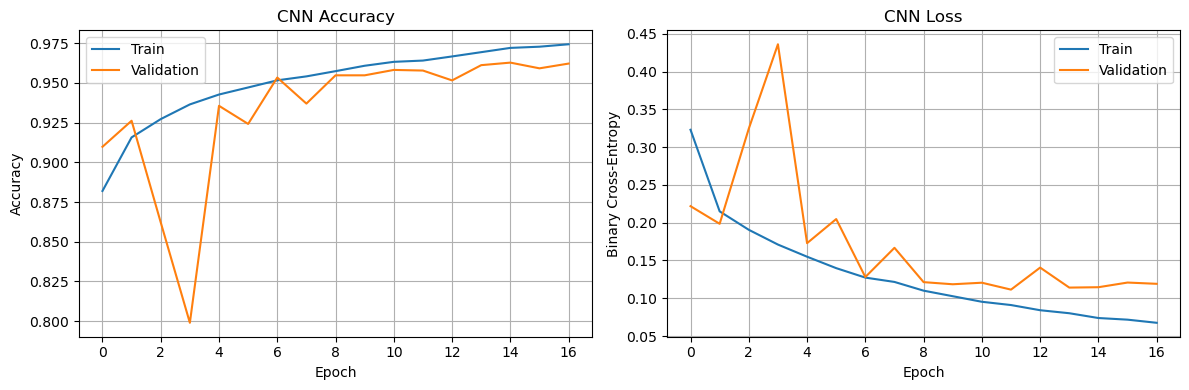

Saved: cnn_training_curves.png


In [45]:
# CNN training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(cnn_history.history['accuracy'], label='Train')
ax1.plot(cnn_history.history['val_accuracy'], label='Validation')
ax1.set_title('CNN Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(cnn_history.history['loss'], label='Train')
ax2.plot(cnn_history.history['val_loss'], label='Validation')
ax2.set_title('CNN Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary Cross-Entropy')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: cnn_training_curves.png")

In [21]:
# CNN evaluation
cnn_probs = cnn.predict(x_test_norm, verbose=0).flatten()
cnn_preds = (cnn_probs >= 0.5).astype(int)
cnn_acc = accuracy_score(y_test_bin, cnn_preds)

print(f"CNN Test Accuracy: {cnn_acc * 100:.2f}%")
print()
print(classification_report(y_test_bin, cnn_preds, target_names=['Animal', 'Vehicle']))

CNN Test Accuracy: 95.56%

              precision    recall  f1-score   support

      Animal       0.97      0.96      0.96      6000
     Vehicle       0.94      0.95      0.94      4000

    accuracy                           0.96     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.96      0.96      0.96     10000



### 5. Confusion Matrices

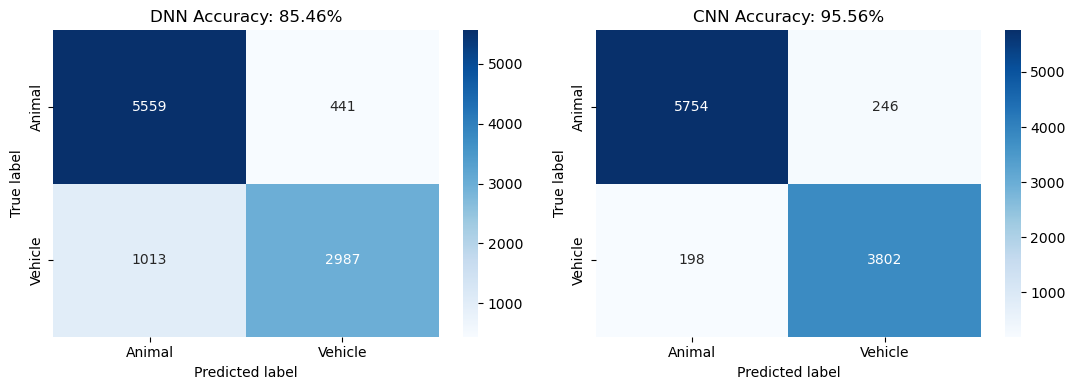

Saved: confusion_matrices.png


In [47]:
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Animal', 'Vehicle'],
                yticklabels=['Animal', 'Vehicle'],
                ax=ax)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion_matrix(y_test_bin, dnn_preds, f'DNN Accuracy: {dnn_acc*100:.2f}%', ax1)
plot_confusion_matrix(y_test_bin, cnn_preds, f'CNN Accuracy: {cnn_acc*100:.2f}%', ax2)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

### 6. Summary Comparison

In [55]:
summary = pd.DataFrame({
    'Model': ['DNN', 'CNN'],
    'Input': ['Flat 3072-dim', '32×32×3 image'],
    'Parameters': [dnn.count_params(), cnn.count_params()],
    'Test Accuracy': [f"{dnn_acc*100:.2f}%", f"{cnn_acc*100:.2f}%"]
})

print(summary.to_string(index=False))

Model         Input  Parameters Test Accuracy
  DNN Flat 3072-dim     1737729        85.46%
  CNN 32×32×3 image     1115041        95.56%
